In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### T-test结果可视化

In [2]:
day = 1600 # setting
t_results = pd.read_csv(f'../processed_data/t_test_results_{day}.csv')
t_results.head()

,Unnamed: 0,factor,mean,std,t_statistic,p_value
0,59,factor_59,0.011643,0.143355,25.141644,0.0
1,52,factor_52,0.007325,0.140331,16.158222,0.0
2,51,factor_51,0.010316,0.133418,23.937151,0.0
3,50,factor_50,0.006272,0.141158,13.755224,0.0
4,55,factor_55,0.006721,0.140966,14.758641,0.0


In [3]:
# 将t检验结果按p值升序排列
t_results_sorted = t_results.sort_values(by='t_statistic', ascending=False)
t_results_sorted.head(20)

,Unnamed: 0,factor,mean,std,t_statistic,p_value
15,54,factor_54,0.010984,0.132088,25.742238,0.000000e+00
0,59,factor_59,0.011643,0.143355,25.141644,0.000000e+00
2,51,factor_51,0.010316,0.133418,23.937151,0.000000e+00
14,60,factor_60,0.010766,0.149930,22.228153,0.000000e+00
1,52,factor_52,0.007325,0.140331,16.158222,0.000000e+00
4,55,factor_55,0.006721,0.140966,14.758641,0.000000e+00
3,50,factor_50,0.006272,0.141158,13.755224,0.000000e+00
8,34,factor_34,0.005133,0.126088,12.603005,0.000000e+00
10,58,factor_58,0.005562,0.152260,11.308512,0.000000e+00
7,35,factor_35,0.003777,0.127208,9.191870,0.000000e+00


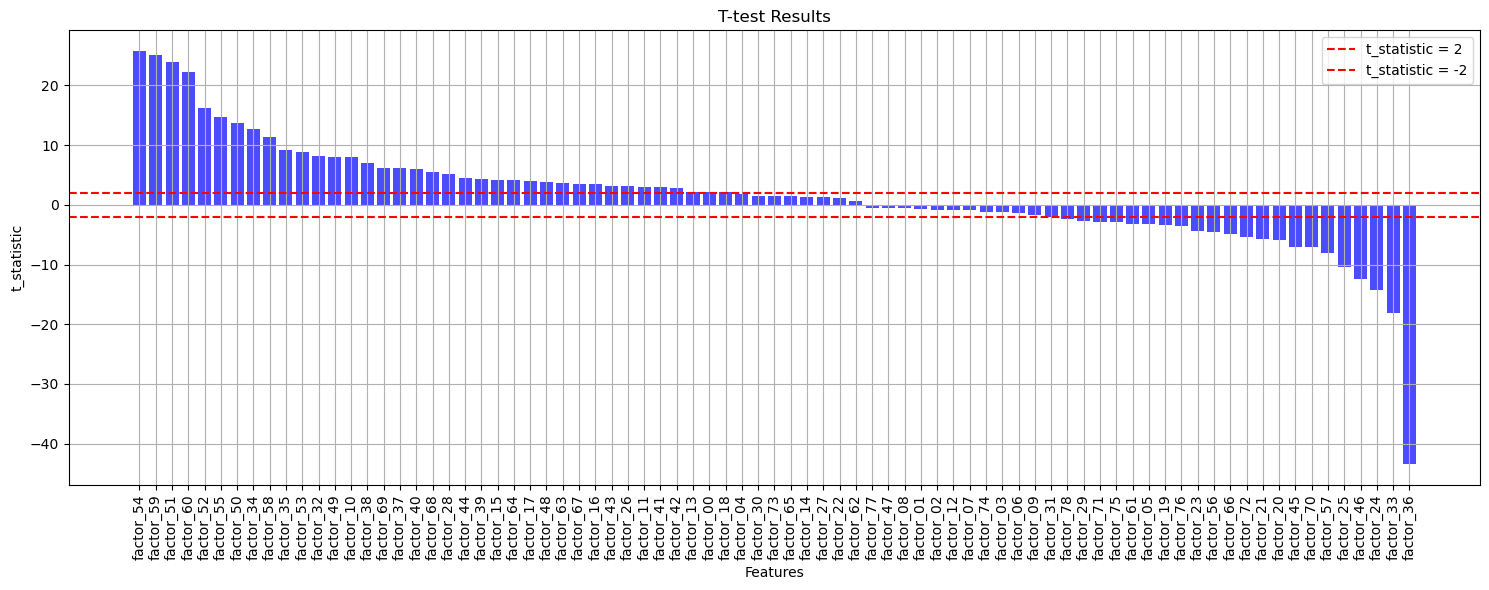

In [4]:
# 绘制t检验结果柱状图（基于t_results_sorted），横轴是79个特征，纵轴是't_statistic'这一列的取值。在t_statistic为+2和-2的地方画上红色虚线。
plt.figure(figsize=(15, 6))
plt.bar(t_results_sorted['factor'], t_results_sorted['t_statistic'], color='blue', alpha=0.7)
plt.axhline(y=2, color='red', linestyle='--', label='t_statistic = 2')
plt.axhline(y=-2, color='red', linestyle='--', label='t_statistic = -2')
plt.xlabel('Features')
plt.ylabel('t_statistic')
plt.title('T-test Results')
plt.xticks(rotation=90)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


### 对原始因子进行EDA

In [4]:
raw_factor = pd.read_parquet(f'../data/output/Factor_compute_{day}.parquet')
raw_factor.head(40)

,date_id,time_id,factor_00,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,factor_07,...,factor_69,factor_70,factor_71,factor_72,factor_73,factor_74,factor_75,factor_76,factor_77,factor_78
0,1600,0,-0.388159,-0.392169,0.441118,0.292936,-0.237213,-0.460508,-0.240470,0.574319,...,-0.244297,-0.173421,-0.520945,-0.581773,0.484532,0.484532,-0.885424,-0.665936,-0.620816,-0.734692
1,1600,1,0.067690,-0.064246,0.524310,-0.047003,0.092722,0.067377,0.146826,0.081792,...,-0.095162,-0.245211,-0.547847,-0.489991,0.261285,0.261285,-0.353504,-0.556902,-0.571464,-0.305536
2,1600,2,-0.271670,-0.049937,-0.041185,-0.126318,-0.298443,0.008601,0.087331,-0.032065,...,0.233117,-0.342536,-0.450456,-0.376506,0.278819,0.278819,-0.361650,-0.431012,-0.294081,-0.222159
3,1600,3,0.109686,-0.004317,0.156303,0.069292,-0.402638,-0.033009,0.329742,0.064283,...,-0.040918,-0.183785,-0.453449,-0.588407,0.345269,0.345269,-0.059165,-0.200939,-0.027175,-0.027175
4,1600,4,-0.003057,0.075260,-0.053826,0.481526,0.045749,-0.141084,0.032314,0.258650,...,0.026715,-0.178769,-0.572487,-0.547269,0.520609,0.520609,-0.388066,-0.279394,-0.252856,-0.195233
5,1600,5,0.092656,-0.104644,-0.176723,0.060671,-0.210714,-0.011937,0.263054,0.057206,...,-0.060434,-0.040418,0.038394,0.054792,0.390370,0.390370,-0.055822,-0.151134,-0.269986,-0.286431
6,1600,6,0.239819,-0.170792,-0.159542,0.186015,0.449199,-0.203332,-0.330328,0.329544,...,-0.121706,0.078200,-0.112974,-0.422041,0.251882,0.251882,-0.370470,-0.304604,0.055618,-0.065525
7,1600,7,0.291113,-0.363174,-0.363734,-0.146957,-0.104339,-0.421754,0.197355,0.064904,...,0.120017,-0.164728,0.057022,-0.032175,0.470432,0.470432,-0.501775,-0.436832,-0.250188,-0.122857
8,1600,8,0.500479,0.047681,0.044669,0.098069,-0.405871,-0.178122,0.275299,0.057752,...,0.121369,-0.495894,-0.284890,-0.189888,0.330099,0.330099,-0.471032,-0.270044,-0.077851,0.225535
9,1600,9,0.353178,0.325506,-0.007441,0.021406,-0.598882,0.324640,-0.042421,-0.128275,...,0.050406,0.486520,0.381957,-0.128360,-0.135799,-0.135799,-0.362720,-0.637332,-0.190530,-0.188629


In [5]:
raw_factor = pd.read_parquet(f'../data/output/Factor_compute_{day}.parquet')
raw_factor.head()

,date_id,time_id,factor_00,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,factor_07,...,factor_69,factor_70,factor_71,factor_72,factor_73,factor_74,factor_75,factor_76,factor_77,factor_78
0,1600,0,-0.388159,-0.392169,0.441118,0.292936,-0.237213,-0.460508,-0.240470,0.574319,...,-0.244297,-0.173421,-0.520945,-0.581773,0.484532,0.484532,-0.885424,-0.665936,-0.620816,-0.734692
1,1600,1,0.067690,-0.064246,0.524310,-0.047003,0.092722,0.067377,0.146826,0.081792,...,-0.095162,-0.245211,-0.547847,-0.489991,0.261285,0.261285,-0.353504,-0.556902,-0.571464,-0.305536
2,1600,2,-0.271670,-0.049937,-0.041185,-0.126318,-0.298443,0.008601,0.087331,-0.032065,...,0.233117,-0.342536,-0.450456,-0.376506,0.278819,0.278819,-0.361650,-0.431012,-0.294081,-0.222159
3,1600,3,0.109686,-0.004317,0.156303,0.069292,-0.402638,-0.033009,0.329742,0.064283,...,-0.040918,-0.183785,-0.453449,-0.588407,0.345269,0.345269,-0.059165,-0.200939,-0.027175,-0.027175
4,1600,4,-0.003057,0.075260,-0.053826,0.481526,0.045749,-0.141084,0.032314,0.258650,...,0.026715,-0.178769,-0.572487,-0.547269,0.520609,0.520609,-0.388066,-0.279394,-0.252856,-0.195233


In [6]:
raw_factor.describe()

,date_id,time_id,factor_00,factor_01,factor_02,factor_03,factor_04,factor_05,factor_06,factor_07,...,factor_69,factor_70,factor_71,factor_72,factor_73,factor_74,factor_75,factor_76,factor_77,factor_78
count,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,...,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000,95832.000000
mean,1649.000000,483.500000,0.000864,-0.000271,-0.000350,-0.000498,0.000703,-0.001352,-0.000596,-0.000363,...,0.002833,-0.003235,-0.001309,-0.002464,0.000601,-0.000514,-0.001244,-0.001528,-0.000205,-0.001000
std,28.577529,279.438839,0.125261,0.126120,0.126377,0.126133,0.126118,0.130569,0.130344,0.130247,...,0.143181,0.140439,0.137772,0.141110,0.132817,0.132489,0.130658,0.130584,0.132797,0.131998
min,1600.000000,0.000000,-1.169133,-1.149463,-0.861787,-0.955520,-1.169908,-1.000202,-0.977828,-0.995019,...,-1.184638,-1.090675,-1.113258,-1.142352,-0.959733,-0.798139,-1.037158,-1.041384,-0.866447,-0.853672
25%,1624.000000,241.750000,-0.073184,-0.074058,-0.074833,-0.074568,-0.073184,-0.076559,-0.076395,-0.076522,...,-0.076431,-0.082113,-0.078130,-0.081362,-0.075130,-0.076522,-0.076837,-0.076955,-0.077237,-0.077995
50%,1649.000000,483.500000,0.000302,0.000201,0.000366,0.000384,0.000763,-0.000273,-0.000281,-0.000190,...,0.003202,-0.001809,0.000474,-0.001413,0.000828,0.000433,-0.001113,-0.000963,-0.000057,-0.001033
75%,1674.000000,725.250000,0.074137,0.073925,0.073931,0.074119,0.074902,0.075244,0.075929,0.075834,...,0.083453,0.077924,0.077655,0.078273,0.077345,0.076588,0.075435,0.074755,0.076798,0.075627
max,1698.000000,967.000000,1.086848,1.266171,0.864508,0.957160,1.043114,0.839966,1.123283,0.836333,...,1.057676,1.079747,0.977641,1.038358,0.883229,0.864248,1.015609,1.015585,1.079935,0.886028


In [8]:
raw_factor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 81 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_id    95832 non-null  int64  
 1   time_id    95832 non-null  int64  
 2   factor_00  95832 non-null  float64
 3   factor_01  95832 non-null  float64
 4   factor_02  95832 non-null  float64
 5   factor_03  95832 non-null  float64
 6   factor_04  95832 non-null  float64
 7   factor_05  95832 non-null  float64
 8   factor_06  95832 non-null  float64
 9   factor_07  95832 non-null  float64
 10  factor_08  95832 non-null  float64
 11  factor_09  95832 non-null  float64
 12  factor_10  95832 non-null  float64
 13  factor_11  95832 non-null  float64
 14  factor_12  95832 non-null  float64
 15  factor_13  95832 non-null  float64
 16  factor_14  95832 non-null  float64
 17  factor_15  95832 non-null  float64
 18  factor_16  95832 non-null  float64
 19  factor_17  95832 non-null  float64
 20  factor

In [10]:
import pandas as pd

# 初始化一个空的DataFrame用于存储统计结果
stats_df = pd.DataFrame(columns=[
    "column", 'unique', "cardinality", "with_null", 
    "null_pct", "1st_row", "last_row", "dtype",'mean', 'std', 'min', 'max'
])

# 遍历raw_factor的每一列
for col in raw_factor.columns:
    # 计算列中唯一值的数量
    unique_count = raw_factor[col].nunique()
    
    # 判断是否所有值都是唯一的
    is_unique = unique_count == len(raw_factor)
    
    # 检查列是否包含空值
    with_null = raw_factor[col].isna().sum() > 0
    
    # 计算空值的百分比
    null_pct = (raw_factor[col].isna().sum() / len(raw_factor)) * 100
    
    # 获取第一个值，如果为空则使用0.0作为默认值
    first_row = raw_factor[col].iloc[0]
    if pd.isna(first_row):
        first_row = 0.0
    else:
        first_row = float(first_row)
    
    # 获取最后一个值，如果为空则使用0.0作为默认值
    last_row = raw_factor[col].iloc[-1]
    if pd.isna(last_row):
        last_row = 0.0
    else:
        last_row = float(last_row)
    
    # 获取列的数据类型
    dtype = str(raw_factor[col].dtype)
    
    #mean
    mean = raw_factor[col].mean()
    
    # std
    std = raw_factor[col].std()
    
    # min
    min = raw_factor[col].min()
    
    # max
    max = raw_factor[col].max()
    
    # 创建包含统计信息的新行
    new_data = pd.DataFrame({
        "column": [col],
        'unique': [is_unique],
        "cardinality": [unique_count],
        "with_null": [with_null],
        "null_pct": [null_pct],
        "1st_row": [first_row],
        "last_row": [last_row],
        "dtype": [dtype],
        "mean":[mean],
        "std":[std],
        "min":[min],
        'max':[max]
    })
    
    # 将统计信息添加到DataFrame中
    stats_df = pd.concat([stats_df, new_data], ignore_index=True)

# 显示结果
stats_df

/var/folders/_m/7_bm67yd2rnf1kspxw748hlc0000gn/T/ipykernel_62773/2499246247.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, new_data], ignore_index=True)


,column,unique,cardinality,with_null,null_pct,1st_row,last_row,dtype,mean,std,min,max
0,date_id,False,99,False,0.0,1600.000000,1698.000000,int64,1649.000000,28.577529,1600,1698
1,time_id,False,968,False,0.0,0.000000,967.000000,int64,483.500000,279.438839,0,967
2,factor_00,True,95832,False,0.0,-0.388159,0.055816,float64,0.000864,0.125261,-1.169133,1.086848
3,factor_01,True,95832,False,0.0,-0.392169,0.123452,float64,-0.000271,0.126120,-1.149463,1.266171
4,factor_02,False,95831,False,0.0,0.441118,-0.083580,float64,-0.000350,0.126377,-0.861787,0.864508
...,...,...,...,...,...,...,...,...,...,...,...,...
76,factor_74,True,95832,False,0.0,0.484532,0.035688,float64,-0.000514,0.132489,-0.798139,0.864248
77,factor_75,False,95831,False,0.0,-0.885424,-0.053534,float64,-0.001244,0.130658,-1.037158,1.015609
78,factor_76,True,95832,False,0.0,-0.665936,-0.041426,float64,-0.001528,0.130584,-1.041384,1.015585
79,factor_77,False,95831,False,0.0,-0.620816,0.050653,float64,-0.000205,0.132797,-0.866447,1.079935


In [11]:
stats_df.to_csv('../processed_data/Factor_EDA.csv')

In [9]:
index_cols = ['date_id', 'time_id']
feature_cols = [col for col in raw_factor.columns if col not in index_cols]

In [10]:
raw_factor[feature_cols].corr

<bound method DataFrame.corr of        factor_00  factor_01  factor_02  factor_03  factor_04  factor_05  \
0      -0.388159  -0.392169   0.441118   0.292936  -0.237213  -0.460508   
1       0.067690  -0.064246   0.524310  -0.047003   0.092722   0.067377   
2      -0.271670  -0.049937  -0.041185  -0.126318  -0.298443   0.008601   
3       0.109686  -0.004317   0.156303   0.069292  -0.402638  -0.033009   
4      -0.003057   0.075260  -0.053826   0.481526   0.045749  -0.141084   
...          ...        ...        ...        ...        ...        ...   
95827   0.084052  -0.005758  -0.073912   0.078501  -0.110602   0.138939   
95828  -0.066046  -0.046246  -0.183395  -0.081345  -0.076600   0.075176   
95829  -0.003138  -0.118903  -0.061350  -0.044345  -0.033796   0.031019   
95830  -0.039418   0.058081  -0.090511   0.024045  -0.045295   0.208026   
95831   0.055816   0.123452  -0.083580  -0.097224   0.067301   0.051420   

       factor_06  factor_07  factor_08  factor_09  ...  factor_69  

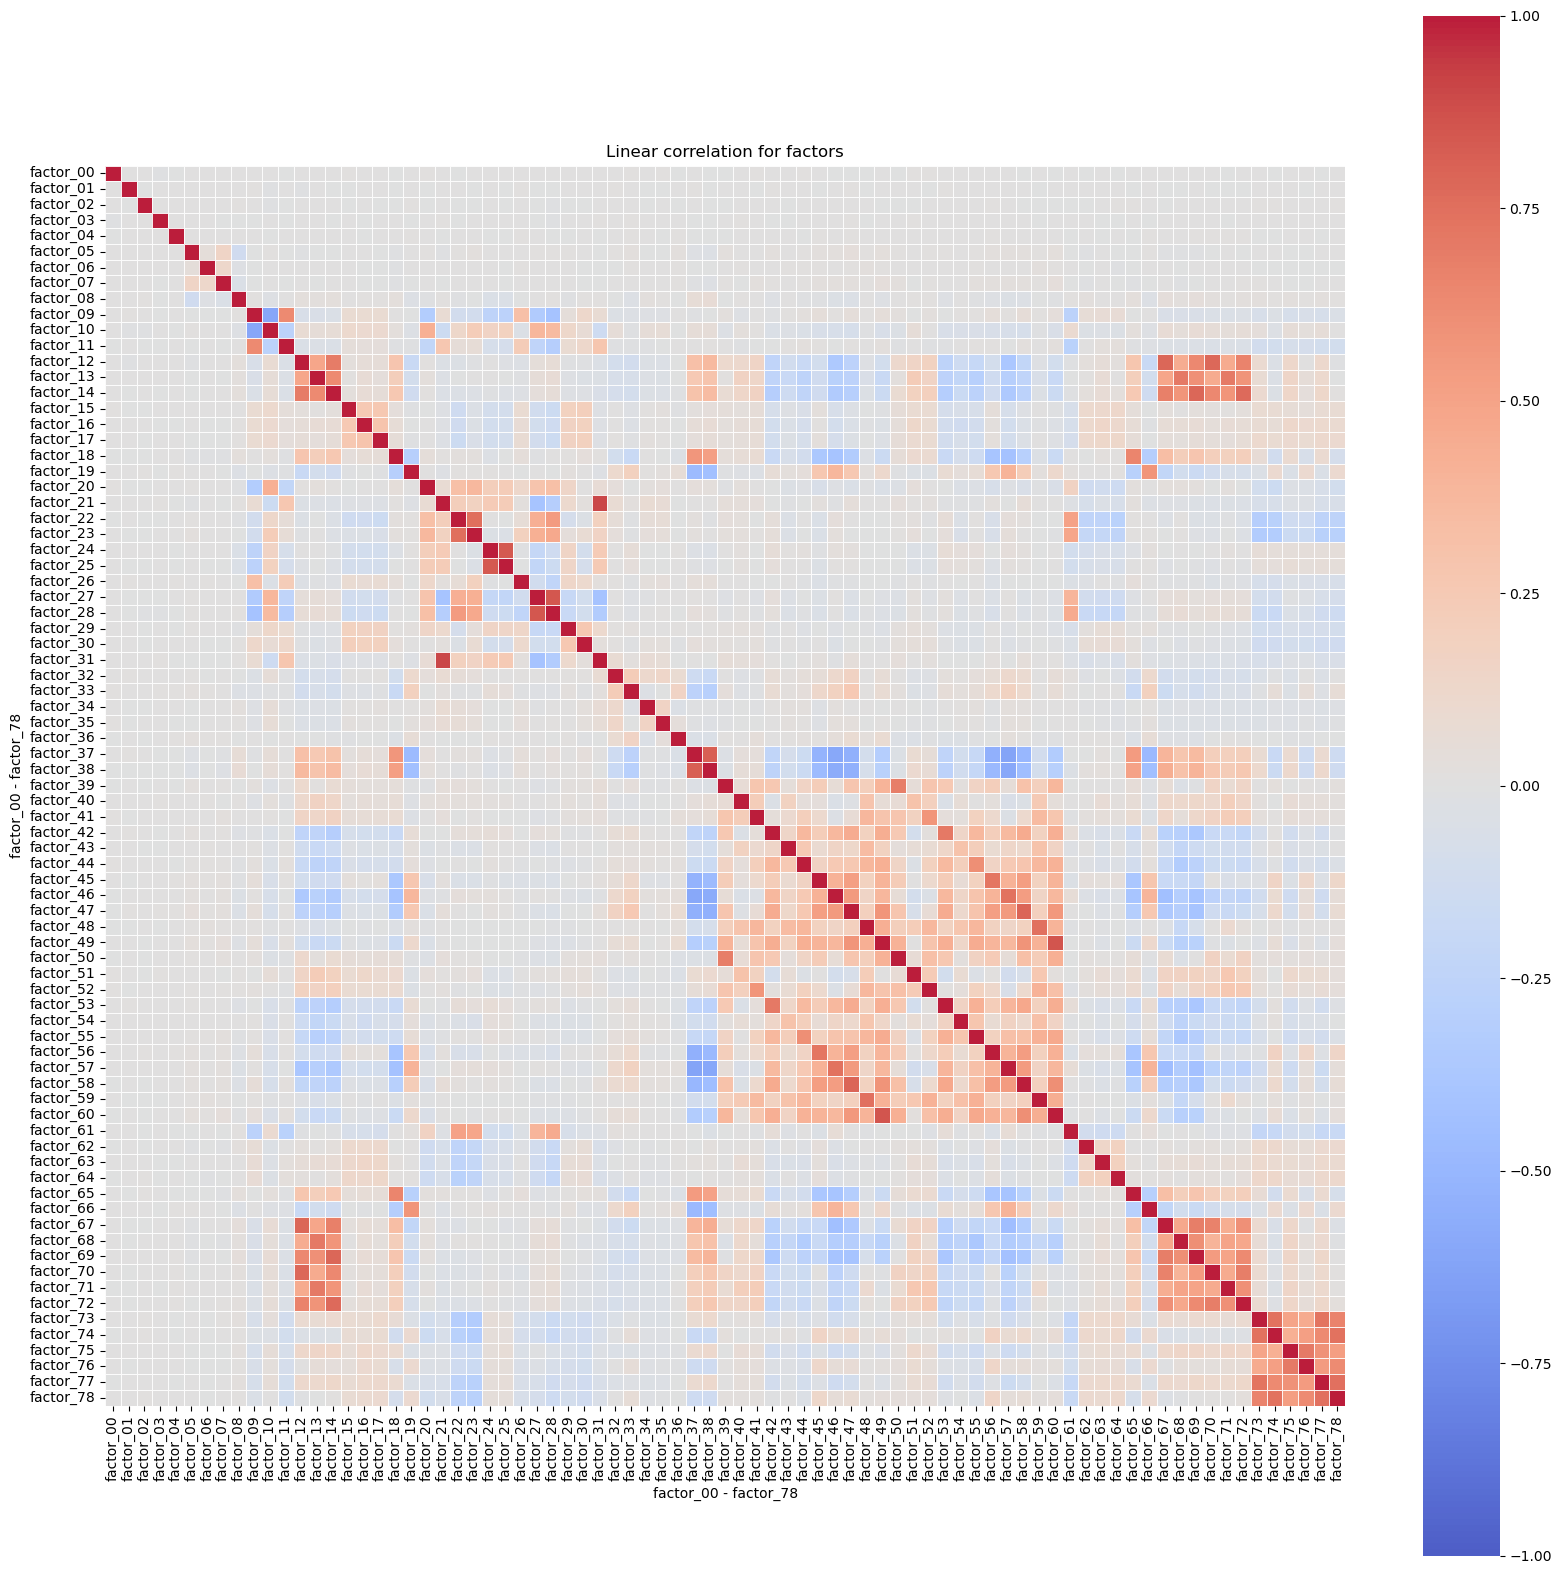

In [15]:
import seaborn as sns
matrix_pd = raw_factor[feature_cols].corr()

# plot the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(matrix_pd, square=True, cmap="coolwarm", alpha=0.9, vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white')
plt.xlabel("factor_00 - factor_78")
plt.ylabel("factor_00 - factor_78")
plt.title('Linear correlation for factors')
plt.show()

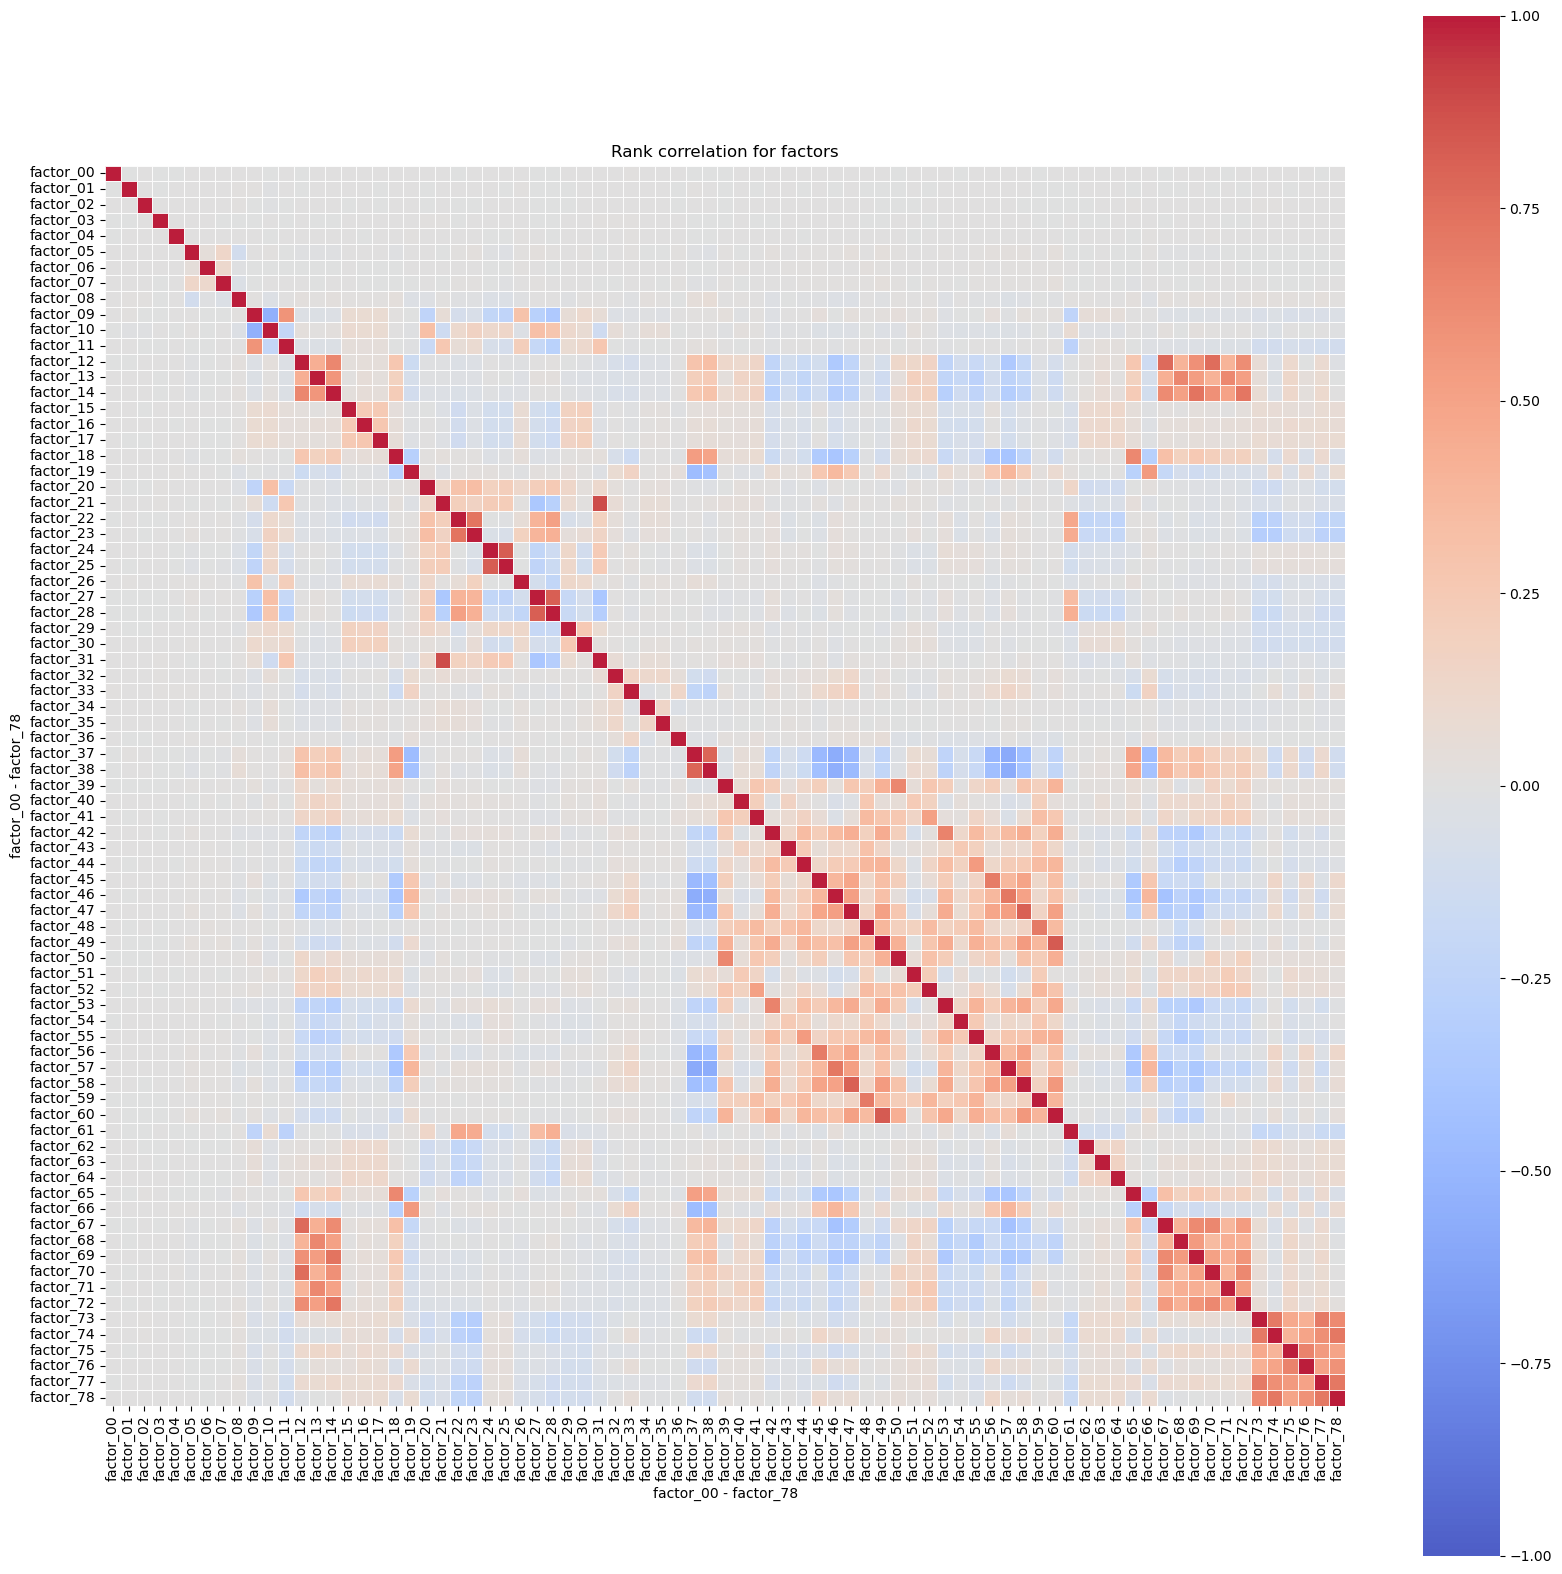

In [16]:
import seaborn as sns
matrix_pd = raw_factor[feature_cols].corr(method = 'spearman')

# plot the heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(matrix_pd, square=True, cmap="coolwarm", alpha=0.9, vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor='white')
plt.xlabel("factor_00 - factor_78")
plt.ylabel("factor_00 - factor_78")
plt.title('Rank correlation for factors')
plt.show()